# Notebook 11 — Bias / Fairness Robustness Analysis (Phase 3, MVP 4 family)

**Purpose.** Test whether the four MVP 4 variants exhibit measurable bias-profile
differences across (a) identity-term masking, (b) counterfactual identity swap,
and (c) per-community performance stratification. The bias-off ablation in
NB 10-lower / `outputs/diagnostic/mvp4_corrected_comparison.md` showed the
IW mechanism contributes ~ 0 to final predictions (Δ = +0.0002 NotHate F1,
9,999 / 10,000 sample agreement). This notebook tests whether that finding
extends to bias-robustness: if the mechanism is decorative for aggregate
metrics, it should also be decorative for bias profile.

## Three analyses

**Analysis 1 — Identity-Term Masking flip rate.** For every test sample with
identity-token presence, build a masked version where lexicon-matched BPE
positions are replaced with `<mask>` (the tokenizer's mask token, ID =
`tokenizer.mask_token_id`). Run inference on both the original and masked
versions for all four variants. Compute the **flip rate** = % of samples
where the fused T1 prediction changes between original and masked. Higher
flip rate means the model is more reliant on the identity terminology
itself (sensitive to identity terms rather than substantive content).
Stratify by:

- T1 label (hate vs nothate)
- Per-community (Islam, African, Jewish, Refugee, Homosexual, Women, Arab,
  Asian, Caucasian, Hispanic — communities with ≥ 30 lexicon tokens)

Target: < 15 % flip rate per community.

**Analysis 2 — Counterfactual Identity Swap.** For each predefined swap
pair (e.g., `muslim` ↔ `christian`), find samples containing the source
word, replace it with the target word, run inference on both versions for
all four variants. Compute flip rate per pair per variant. Asymmetric flip
rates (e.g., `muslim → christian` flips more often than `christian → muslim`)
indicate community-specific bias. Swap pairs are predefined upfront for
reproducibility (Cell 4).

**Analysis 3 — Per-Community Performance.** For each of the top-10
high-population communities, identify test samples whose identity tokens
target that community, and compute T1 accuracy, FPR, and T2 macro F1 per
variant on that subgroup. 95 % bootstrap CIs from 1,000 resamples
(seed 42). Compare across variants.

## Success criteria

- All four variants exhibit per-community flip rate < 15 % (target threshold)
- Per-community accuracy disparities < 0.10 (Δ between best and worst
  community per variant)
- MVP 4-IW-CC-S exhibits bias profile statistically equivalent to MVP 4-lower
  (consistent with the bias-off ablation finding)

## Expected outcome (pre-registered)

Given the bias-off ablation result (Δ = +0.0002, 9,999 / 10,000 agreement),
this analysis is expected to confirm that MVP 4-IW-CC-S and MVP 4-lower
produce statistically indistinguishable bias profiles across all three
analyses. If meaningful differences appear, the finding becomes:
"the identity-bias mechanism affects prediction distribution rather than
prediction accuracy" — a different but still informative result.

## Outputs

- `outputs/nb11/01_masking_flip_rate.png`
- `outputs/nb11/02_swap_asymmetry.png`
- `outputs/nb11/03_per_community_accuracy.png`
- `outputs/nb11/table_1_masking.md`
- `outputs/nb11/table_2_swap.md`
- `outputs/nb11/table_3_per_community.md`
- `outputs/nb11/summary.md`
- `data/processed/nb11_per_sample_masking_data.parquet`

In [1]:
# Cell 2: imports, seed, device, paths, variant configs
import os, sys, json, math, time, gc, re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score, confusion_matrix
from transformers import AutoTokenizer, AutoModel, CLIPModel, CLIPVisionModel, CLIPImageProcessor
from peft import PeftModel

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device, "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
OUT_DIR = ROOT / "outputs" / "nb11"
OUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR = ROOT / "data" / "processed"
PER_SAMPLE_PARQUET = ROOT / "data" / "processed" / "nb11_per_sample_masking_data.parquet"

HPARAMS = dict(
    max_len=128, batch_size=32, threshold=0.5,
    confidence_lo=0.4, confidence_hi=0.6, n_bootstrap=1000,
    text_base="cardiffnlp/twitter-roberta-base-2022-154m",
    text_adapter=str(ROOT / "models" / "roberta_mvp1_d"),
    clip_model="openai/clip-vit-base-patch16",
    mvp2_best_dir=str(ROOT / "models" / "mvp2_naive_concat_best"),
    mvp3_best_dir=str(ROOT / "models" / "mvp3_three_branch_best"),
    lexicon_path=str(ROOT / "data" / "processed" / "identity_lexicon.json"),
    splits_dir=str(ROOT / "data" / "MMHS150K" / "splits"),
    img_dir=str(ROOT / "data" / "MMHS150K" / "img_resized"),
    labels_csv=str(ROOT / "data" / "processed" / "labels_parsed.csv"),
    struct_csv=str(ROOT / "data" / "processed" / "structured_features.csv"),
    nb10_lower_parquet=str(ROOT / "data" / "processed" / "nb10_lower_per_sample_data.parquet"),
    masking_target=0.15,  # success criterion threshold for flip rate
)

VARIANTS = [
    {"name": "mvp4_lower",  "label": "MVP 4-lower",  "arch": "standard",
     "best_dir": str(ROOT / "models" / "mvp4_gated_fusion_lowercase_best"),
     "ckpt_file": "mvp4_trainable.pt", "alpha_init": None, "lambda_id_init": None,
     "has_pre_gate_ln": False, "mu_vneg_train": None},
    {"name": "mvp4_iw",     "label": "MVP 4-IW",     "arch": "iw",
     "best_dir": str(ROOT / "models" / "mvp4_iw_attention_best"),
     "ckpt_file": "mvp4_iw_trainable.pt", "alpha_init": None, "lambda_id_init": 1.0,
     "has_pre_gate_ln": False, "mu_vneg_train": None},
    {"name": "mvp4_iwcc",   "label": "MVP 4-IW-CC",  "arch": "iwcc",
     "best_dir": str(ROOT / "models" / "mvp4_iwcc_attention_best"),
     "ckpt_file": "mvp4_iwcc_trainable.pt", "alpha_init": 1.0, "lambda_id_init": 1.0,
     "has_pre_gate_ln": False, "mu_vneg_train": None},
    {"name": "mvp4_iwccs",  "label": "MVP 4-IW-CC-S","arch": "iwccs",
     "best_dir": str(ROOT / "models" / "mvp4_iwccs_attention_best"),
     "ckpt_file": "mvp4_iwccs_trainable.pt", "alpha_init": 0.5, "lambda_id_init": 1.0,
     "has_pre_gate_ln": True, "mu_vneg_train": 0.17250415368639668},
]
print("paths configured")
print("variants:"); [print("  ", v["name"], v["arch"]) for v in VARIANTS]

device: cuda | NVIDIA L4
paths configured
variants:
   mvp4_lower standard
   mvp4_iw iw
   mvp4_iwcc iwcc
   mvp4_iwccs iwccs


[None, None, None, None]

In [2]:
# Cell 3: load test data + identity lexicon + NB10-lower per-sample parquet
from pathlib import Path as _P

labels = pd.read_csv(HPARAMS["labels_csv"])
struct = pd.read_csv(HPARAMS["struct_csv"])
merged = labels.merge(struct, on="tweet_id", how="inner")

def _load_split(name):
    p = _P(HPARAMS["splits_dir"]) / f"{name}_ids.txt"
    return {int(line.strip().split('.')[0]) for line in p.read_text().splitlines() if line.strip()}

test_ids = _load_split("test")
test = merged[merged["tweet_id"].isin(test_ids)].reset_index(drop=True).copy()
print(f"test rows: {test.shape}  T1 hate frac: {test['T1'].mean():.4f}  t2_valid: {int(test['t2_valid'].sum()):,}")

# Load identity lexicon with community mappings
with open(HPARAMS["lexicon_path"], "r") as f:
    lex_payload = json.load(f)
LEXICON_TOKENS = {entry["token"].lower() for entry in lex_payload["tokens"]}
# token -> communities (list)
TOKEN_TO_COMMUNITIES = {entry["token"].lower(): list(entry.get("communities", []))
                        for entry in lex_payload["tokens"]}
print(f"lexicon: {len(LEXICON_TOKENS)} tokens / {lex_payload['n_communities']} communities")

# Identity-token presence per sample (sample-level definition, same as NB10)
WORD_RE = re.compile(r"[a-z0-9_']+", re.UNICODE)

def identity_tokens_in_text(text):
    text_lower = (text or "").lower()
    hits = []
    for m in WORD_RE.finditer(text_lower):
        w = m.group()
        if w in LEXICON_TOKENS:
            hits.append(w)
    return hits

test["id_tokens"] = test["tweet_text"].map(identity_tokens_in_text)
test["has_identity_token"] = test["id_tokens"].map(len) >= 1
print(f"identity-laden samples in test: {int(test['has_identity_token'].sum()):,}")

# Sample-level community membership: union of communities across all hit tokens
def sample_communities(hits):
    s = set()
    for t in hits:
        for c in TOKEN_TO_COMMUNITIES.get(t, []):
            s.add(c)
    return sorted(s)
test["communities"] = test["id_tokens"].map(sample_communities)

# Community → set of sample tweet_ids
COMMUNITIES_TOP10 = ["Islam","African","Jewish","Refugee","Homosexual",
                     "Women","Arab","Asian","Caucasian","Hispanic"]
print("\nper-community sample counts (top-10):")
for c in COMMUNITIES_TOP10:
    n_total = int(test["communities"].map(lambda L: c in L).sum())
    n_hate  = int(((test["communities"].map(lambda L: c in L)) & (test["T1"] == 1)).sum())
    n_nhate = int(((test["communities"].map(lambda L: c in L)) & (test["T1"] == 0)).sum())
    print(f"  {c:<12}  total={n_total:>5}  hate={n_hate:>4}  nothate={n_nhate:>4}")

# Load NB10-lower per-sample data for original predictions
df_nb10 = pd.read_parquet(HPARAMS["nb10_lower_parquet"])
df_nb10 = df_nb10[df_nb10["variant"].isin([v["name"] for v in VARIANTS])]
print(f"\nNB10-lower parquet: {df_nb10.shape}  (4 variants × 10K)")

test rows: (10000, 19)  T1 hate frac: 0.5001  t2_valid: 8,411
lexicon: 1177 tokens / 15 communities
identity-laden samples in test: 9,518

per-community sample counts (top-10):
  Islam         total=  484  hate= 279  nothate= 205
  African       total= 5208  hate=2004  nothate=3204
  Jewish        total=  450  hate= 217  nothate= 233
  Refugee       total=  698  hate= 372  nothate= 326
  Homosexual    total= 2048  hate=1271  nothate= 777
  Women         total= 3210  hate=1639  nothate=1571
  Arab          total=  316  hate= 177  nothate= 139
  Asian         total=  364  hate= 186  nothate= 178
  Caucasian     total= 1377  hate= 784  nothate= 593
  Hispanic      total=  385  hate= 209  nothate= 176



NB10-lower parquet: (40000, 33)  (4 variants × 10K)


In [3]:
# Cell 4: swap pairs definition
# Each pair: (source_word, target_word). Both must be in the lexicon.
# We swap source→target on samples containing source word, AND target→source
# on samples containing target word, to measure asymmetry.
SWAP_PAIRS = [
    ("muslim",   "christian"),
    ("muslims",  "christians"),
    ("islam",    "christianity"),
    ("muslim",   "jew"),
    ("muslims",  "jews"),
    ("black",    "white"),
    ("blacks",   "whites"),
    ("africans", "caucasians"),
    ("gay",      "straight"),       # straight may or may not be in lexicon
    ("woman",    "man"),
    ("women",    "men"),
    ("jew",      "muslim"),         # reverse of pair above (different sample subset)
    ("jews",     "muslims"),
    ("christian","muslim"),
    ("christians","muslims"),
    ("white",    "black"),
    ("whites",   "blacks"),
    ("man",      "woman"),
    ("men",      "women"),
]
# Filter to pairs where both words are in the lexicon (so identity_mask construction
# is sensible for both directions and we can compute the swap reliably).
SWAP_PAIRS_VALID = [(a, b) for a, b in SWAP_PAIRS
                    if a in LEXICON_TOKENS and b in LEXICON_TOKENS]
print(f"defined {len(SWAP_PAIRS)} swap pairs; {len(SWAP_PAIRS_VALID)} pass lexicon-membership filter:")
for a, b in SWAP_PAIRS_VALID:
    n = int(test["id_tokens"].map(lambda L, w=a: w in L).sum())
    print(f"  {a:>14}  →  {b:<14}  source-present in {n:>4} test samples")

defined 19 swap pairs; 19 pass lexicon-membership filter:
          muslim  →  christian       source-present in    7 test samples
         muslims  →  christians      source-present in    1 test samples
           islam  →  christianity    source-present in   11 test samples
          muslim  →  jew             source-present in    7 test samples
         muslims  →  jews            source-present in    1 test samples
           black  →  white           source-present in  116 test samples
          blacks  →  whites          source-present in    3 test samples
        africans  →  caucasians      source-present in    1 test samples
             gay  →  straight        source-present in   64 test samples
           woman  →  man             source-present in   24 test samples
           women  →  men             source-present in   32 test samples
             jew  →  muslim          source-present in    2 test samples
            jews  →  muslims         source-present in    2 test s

In [4]:
# Cell 5: Build the model loader + inference helpers (reused from NB10-lower)
tokenizer = AutoTokenizer.from_pretrained(HPARAMS["text_base"], use_fast=True)
image_processor = CLIPImageProcessor.from_pretrained(HPARAMS["clip_model"])
MASK_TOKEN_ID = tokenizer.mask_token_id
print(f"tokenizer mask_token = {tokenizer.mask_token!r}  ID = {MASK_TOKEN_ID}")

with open(_P(HPARAMS["mvp3_best_dir"]) / "standardisation_stats.json", "r") as f:
    STRUCT_STATS = json.load(f)
STRUCT_FEATURES = STRUCT_STATS["feature_order"]
BINARY_SET = set(STRUCT_STATS["binary_features"])
OCR_LEN_CLIP = float(STRUCT_STATS.get("ocr_len_clip", 389.0))

def standardise_struct(row):
    out = []
    for feat in STRUCT_FEATURES:
        v = float(row[feat])
        if feat in BINARY_SET:
            out.append(v)
        elif feat == "ocr_len":
            v = min(v, OCR_LEN_CLIP)
            m = STRUCT_STATS["feature_means"][feat]; s = STRUCT_STATS["feature_stds"][feat]
            out.append((v - m) / s)
        else:
            m = STRUCT_STATS["feature_means"][feat]; s = STRUCT_STATS["feature_stds"][feat]
            out.append((v - m) / s)
    return out


def compute_identity_mask_bpe(text, max_len):
    text_lower = (text or "").lower()
    id_word_spans = [(m.start(), m.end()) for m in WORD_RE.finditer(text_lower)
                     if m.group() in LEXICON_TOKENS]
    enc = tokenizer(text_lower, padding="max_length", truncation=True, max_length=max_len,
                    return_offsets_mapping=True, return_tensors="pt")
    offsets = enc["offset_mapping"][0]; attn = enc["attention_mask"][0]
    mask = torch.zeros(max_len, dtype=torch.float32)
    if not id_word_spans:
        return mask, enc["input_ids"][0], attn
    for i in range(max_len):
        if attn[i] == 0:
            continue
        ts, te = offsets[i].tolist()
        if ts == 0 and te == 0:
            continue
        for ws, we in id_word_spans:
            if ts < we and te > ws:
                mask[i] = 1.0
                break
    return mask, enc["input_ids"][0], attn


# ---------- attention modules (4 archs) ---------------------------------
class IWAttn(nn.Module):
    def __init__(self, lambda_id_init=1.0):
        super().__init__()
        E, H = 768, 8; self.E, self.H, self.D = E, H, E // H
        self.q_proj = nn.Linear(E, E); self.k_proj = nn.Linear(E, E)
        self.v_proj = nn.Linear(E, E); self.out_proj = nn.Linear(E, E)
        self.attn_dropout = nn.Dropout(0.1)
        self.lambda_id = nn.Parameter(torch.tensor(float(lambda_id_init)))
    def forward(self, q, k, v, identity_mask=None, key_padding_mask=None):
        B, Lq, E = q.shape; Lk = k.shape[1]
        Q = self.q_proj(q).view(B, Lq, self.H, self.D).transpose(1, 2)
        K = self.k_proj(k).view(B, Lk, self.H, self.D).transpose(1, 2)
        V = self.v_proj(v).view(B, Lk, self.H, self.D).transpose(1, 2)
        s = 1.0 / math.sqrt(self.D)
        lg = (Q @ K.transpose(-2, -1)) * s
        if identity_mask is not None:
            lg = lg + (self.lambda_id * identity_mask.to(lg.dtype)).unsqueeze(1).unsqueeze(2)
        if key_padding_mask is not None:
            lg = lg.masked_fill(key_padding_mask.unsqueeze(1).unsqueeze(2), float("-inf"))
        a = F.softmax(lg, dim=-1); a = self.attn_dropout(a)
        o = (a @ V).transpose(1, 2).contiguous().view(B, Lq, E)
        return self.out_proj(o)


class IWCCAttn(nn.Module):
    def __init__(self, lambda_id_init=1.0, alpha_init=1.0):
        super().__init__()
        E, H = 768, 8; self.E, self.H, self.D = E, H, E // H
        self.q_proj = nn.Linear(E, E); self.k_proj = nn.Linear(E, E)
        self.v_proj = nn.Linear(E, E); self.out_proj = nn.Linear(E, E)
        self.attn_dropout = nn.Dropout(0.1)
        self.lambda_id = nn.Parameter(torch.tensor(float(lambda_id_init)))
        self.alpha     = nn.Parameter(torch.tensor(float(alpha_init)))
    def forward(self, q, k, v, identity_mask=None, vader_neg=None, key_padding_mask=None):
        B, Lq, E = q.shape; Lk = k.shape[1]
        Q = self.q_proj(q).view(B, Lq, self.H, self.D).transpose(1, 2)
        K = self.k_proj(k).view(B, Lk, self.H, self.D).transpose(1, 2)
        V = self.v_proj(v).view(B, Lk, self.H, self.D).transpose(1, 2)
        s = 1.0 / math.sqrt(self.D)
        lg = (Q @ K.transpose(-2, -1)) * s
        if identity_mask is not None:
            ctx = (1.0 + self.alpha * vader_neg.to(lg.dtype)).unsqueeze(-1) if vader_neg is not None \
                  else torch.ones_like(identity_mask[:, :1].to(lg.dtype))
            lg = lg + (self.lambda_id * identity_mask.to(lg.dtype) * ctx).unsqueeze(1).unsqueeze(2)
        if key_padding_mask is not None:
            lg = lg.masked_fill(key_padding_mask.unsqueeze(1).unsqueeze(2), float("-inf"))
        a = F.softmax(lg, dim=-1); a = self.attn_dropout(a)
        o = (a @ V).transpose(1, 2).contiguous().view(B, Lq, E)
        return self.out_proj(o)


class IWCCSAttn(nn.Module):
    def __init__(self, lambda_id_init=1.0, alpha_init=0.5):
        super().__init__()
        E, H = 768, 8; self.E, self.H, self.D = E, H, E // H
        self.q_proj = nn.Linear(E, E); self.k_proj = nn.Linear(E, E)
        self.v_proj = nn.Linear(E, E); self.out_proj = nn.Linear(E, E)
        self.attn_dropout = nn.Dropout(0.1)
        self.lambda_id = nn.Parameter(torch.tensor(float(lambda_id_init)))
        self.alpha     = nn.Parameter(torch.tensor(float(alpha_init)))
    def forward(self, q, k, v, identity_mask=None, vader_neg_centered=None, key_padding_mask=None):
        B, Lq, E = q.shape; Lk = k.shape[1]
        Q = self.q_proj(q).view(B, Lq, self.H, self.D).transpose(1, 2)
        K = self.k_proj(k).view(B, Lk, self.H, self.D).transpose(1, 2)
        V = self.v_proj(v).view(B, Lk, self.H, self.D).transpose(1, 2)
        s = 1.0 / math.sqrt(self.D)
        lg = (Q @ K.transpose(-2, -1)) * s
        if identity_mask is not None:
            ctx = (1.0 + self.alpha * vader_neg_centered.to(lg.dtype)).unsqueeze(-1) if vader_neg_centered is not None \
                  else torch.ones_like(identity_mask[:, :1].to(lg.dtype))
            lg = lg + (self.lambda_id * identity_mask.to(lg.dtype) * ctx).unsqueeze(1).unsqueeze(2)
        if key_padding_mask is not None:
            lg = lg.masked_fill(key_padding_mask.unsqueeze(1).unsqueeze(2), float("-inf"))
        a = F.softmax(lg, dim=-1); a = self.attn_dropout(a)
        o = (a @ V).transpose(1, 2).contiguous().view(B, Lq, E)
        return self.out_proj(o)


# ---------- shared model wrapper ----------------------------------------
class NB11Model(nn.Module):
    def __init__(self, vcfg):
        super().__init__()
        self.arch = vcfg["arch"]; self.has_pre_gate_ln = vcfg["has_pre_gate_ln"]
        base_text = AutoModel.from_pretrained(HPARAMS["text_base"])
        self.text_encoder = PeftModel.from_pretrained(base_text, HPARAMS["text_adapter"], is_trainable=False)
        for p in self.text_encoder.parameters(): p.requires_grad = False
        self.text_encoder.eval()
        clip_full = CLIPModel.from_pretrained(HPARAMS["clip_model"])
        vis_proj_weight = clip_full.visual_projection.weight.detach().clone()
        del clip_full; gc.collect()
        vision_base = CLIPVisionModel.from_pretrained(HPARAMS["clip_model"])
        self.vision_encoder = PeftModel.from_pretrained(vision_base, HPARAMS["mvp2_best_dir"], is_trainable=False)
        for p in self.vision_encoder.parameters(): p.requires_grad = False
        self.vision_encoder.eval()
        self.visual_projection_to_512 = nn.Linear(768, 512, bias=False)
        self.visual_projection_to_512.weight.data = vis_proj_weight
        for p in self.visual_projection_to_512.parameters(): p.requires_grad = False
        self.image_projection = nn.Linear(512, 768)
        rest = torch.load(_P(HPARAMS["mvp2_best_dir"]) / "rest.pt", map_location="cpu", weights_only=False)
        self.image_projection.load_state_dict(rest["image_projection"])
        for p in self.image_projection.parameters(): p.requires_grad = False
        del rest

        self.struct_branch = nn.Sequential(nn.Linear(9, 32), nn.ReLU(), nn.Dropout(0.1))

        if self.arch == "standard":
            self.cross_attn = nn.MultiheadAttention(embed_dim=768, num_heads=8, dropout=0.1, batch_first=True)
        elif self.arch == "iw":
            self.cross_attn = IWAttn(lambda_id_init=vcfg["lambda_id_init"])
        elif self.arch == "iwcc":
            self.cross_attn = IWCCAttn(lambda_id_init=vcfg["lambda_id_init"], alpha_init=vcfg["alpha_init"])
        elif self.arch == "iwccs":
            self.cross_attn = IWCCSAttn(lambda_id_init=vcfg["lambda_id_init"], alpha_init=vcfg["alpha_init"])
        self.cross_attn_ln = nn.LayerNorm(768)
        if self.has_pre_gate_ln:
            self.gate_ln_text   = nn.LayerNorm(768)
            self.gate_ln_image  = nn.LayerNorm(768)
            self.gate_ln_struct = nn.LayerNorm(32)
        self.gate = nn.Linear(768 + 768 + 32, 3)
        self.proj_text   = nn.Linear(768, 256)
        self.proj_image  = nn.Linear(768, 256)
        self.proj_struct = nn.Linear(32, 256)
        self.head_t1 = nn.Sequential(nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.1), nn.Linear(128, 1))
        self.head_t2 = nn.Sequential(nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.1), nn.Linear(128, 6))

    def load_ckpt(self, p):
        c = torch.load(p, map_location="cpu", weights_only=False)
        self.struct_branch.load_state_dict(c["struct_branch"])
        self.cross_attn.load_state_dict(c["cross_attn"])
        self.cross_attn_ln.load_state_dict(c["cross_attn_ln"])
        if self.has_pre_gate_ln:
            self.gate_ln_text.load_state_dict(c["gate_ln_text"])
            self.gate_ln_image.load_state_dict(c["gate_ln_image"])
            self.gate_ln_struct.load_state_dict(c["gate_ln_struct"])
        self.gate.load_state_dict(c["gate"])
        self.proj_text.load_state_dict(c["proj_text"])
        self.proj_image.load_state_dict(c["proj_image"])
        self.proj_struct.load_state_dict(c["proj_struct"])
        self.head_t1.load_state_dict(c["head_t1"])
        self.head_t2.load_state_dict(c["head_t2"])

    @torch.no_grad()
    def forward(self, ids, msk, pix, stc, identity_mask=None, vader_centered=None, vader_raw=None):
        t_out = self.text_encoder(input_ids=ids, attention_mask=msk)
        text_tokens = t_out.last_hidden_state; text_cls = text_tokens[:, 0]
        v_out = self.vision_encoder.base_model.model(pixel_values=pix)
        img_768 = self.image_projection(self.visual_projection_to_512(v_out.pooler_output))
        struct_embed = self.struct_branch(stc)
        q = img_768.unsqueeze(1); kpm = (msk == 0)
        if self.arch == "standard":
            attn_out, _ = self.cross_attn(query=q, key=text_tokens, value=text_tokens, key_padding_mask=kpm, need_weights=False)
            attn_out = attn_out.squeeze(1)
        elif self.arch == "iw":
            attn_out = self.cross_attn(q, text_tokens, text_tokens, identity_mask=identity_mask, key_padding_mask=kpm).squeeze(1)
        elif self.arch == "iwcc":
            attn_out = self.cross_attn(q, text_tokens, text_tokens, identity_mask=identity_mask, vader_neg=vader_raw, key_padding_mask=kpm).squeeze(1)
        elif self.arch == "iwccs":
            attn_out = self.cross_attn(q, text_tokens, text_tokens, identity_mask=identity_mask, vader_neg_centered=vader_centered, key_padding_mask=kpm).squeeze(1)
        attended_img = self.cross_attn_ln(img_768 + attn_out)
        if self.has_pre_gate_ln:
            concat = torch.cat([self.gate_ln_text(text_cls), self.gate_ln_image(attended_img), self.gate_ln_struct(struct_embed)], dim=-1)
        else:
            concat = torch.cat([text_cls, attended_img, struct_embed], dim=-1)
        gates = F.softmax(self.gate(concat), dim=-1)
        fused = gates[:,0:1]*self.proj_text(text_cls) + gates[:,1:2]*self.proj_image(attended_img) + gates[:,2:3]*self.proj_struct(struct_embed)
        return self.head_t1(fused).squeeze(-1), self.head_t2(fused)


# ---------- dataset that accepts pre-tokenized (input_ids, attn_mask, identity_mask) ---
class NB11FlexDataset(Dataset):
    def __init__(self, recs):
        self.recs = recs
    def __len__(self):
        return len(self.recs)
    def __getitem__(self, idx):
        return self.recs[idx]

def collate_flex(batch):
    keys = batch[0].keys()
    out = {}
    for k in keys:
        if isinstance(batch[0][k], torch.Tensor):
            out[k] = torch.stack([b[k] for b in batch])
        else:
            out[k] = torch.tensor([b[k] for b in batch])
    return out


# ---------- per-sample record builder ---------------------------------
print("preparing per-sample inference records (image + struct cached once)...")
mu_iwccs = 0.17250415368639668
def build_record(rec, override_text=None):
    text = override_text if override_text is not None else str(rec.get("tweet_text") or "")
    identity_mask, input_ids, attention_mask = compute_identity_mask_bpe(text, HPARAMS["max_len"])
    img = Image.open(_P(HPARAMS["img_dir"]) / f"{int(rec['tweet_id'])}.jpg").convert("RGB")
    px = image_processor(images=img, return_tensors="pt")["pixel_values"].squeeze(0)
    struct = torch.tensor(standardise_struct(rec), dtype=torch.float32)
    vraw = float(rec["vader_neg"])
    vctr = vraw - mu_iwccs
    return {
        "tweet_id": int(rec["tweet_id"]),
        "input_ids": input_ids, "attention_mask": attention_mask,
        "identity_mask": identity_mask, "pixel_values": px,
        "structured": struct,
        "vader_raw": torch.tensor(vraw, dtype=torch.float32),
        "vader_centered": torch.tensor(vctr, dtype=torch.float32),
        "t1_label": torch.tensor(int(rec["T1"]), dtype=torch.float32),
        "t2_label": torch.tensor(int(rec["T2"]) if not pd.isna(rec["T2"]) else 0, dtype=torch.long),
        "t2_valid": torch.tensor(bool(rec.get("t2_valid", False)) and not pd.isna(rec["T2"]), dtype=torch.float32),
    }


def run_forward(model, recs, batch_size=32):
    ds = NB11FlexDataset(recs)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True, collate_fn=collate_flex)
    probs, t2pred, tids = [], [], []
    with torch.no_grad(), torch.amp.autocast("cuda", dtype=torch.float16):
        for batch in loader:
            ids = batch["input_ids"].to(device, non_blocking=True)
            msk = batch["attention_mask"].to(device, non_blocking=True)
            idm = batch["identity_mask"].to(device, non_blocking=True)
            pix = batch["pixel_values"].to(device, non_blocking=True)
            stc = batch["structured"].to(device, non_blocking=True)
            vr  = batch["vader_raw"].to(device, non_blocking=True)
            vc  = batch["vader_centered"].to(device, non_blocking=True)
            lg1, lg2 = model(ids, msk, pix, stc, identity_mask=idm, vader_centered=vc, vader_raw=vr)
            probs.append(torch.sigmoid(lg1.float()).cpu().numpy())
            t2pred.append(lg2.argmax(dim=-1).cpu().numpy())
            tids.append(batch["tweet_id"].cpu().numpy())
    return np.concatenate(probs), np.concatenate(t2pred), np.concatenate(tids)

tokenizer mask_token = '<mask>'  ID = 50264
preparing per-sample inference records (image + struct cached once)...


In [5]:
# Cell 6: Analysis 1 — Identity-Term Masking
# Build masked versions of identity-laden samples and run inference per variant
# (original predictions come from the NB10-lower parquet to save one full pass).

# Subset: identity-laden test samples
laden = test[test["has_identity_token"]].reset_index(drop=True)
print(f"identity-laden samples for masking: {len(laden):,}")

def build_masked_record(rec):
    '''Same as build_record but replaces lexicon-tagged BPE positions with <mask>.'''
    text = str(rec.get("tweet_text") or "")
    identity_mask, input_ids, attention_mask = compute_identity_mask_bpe(text, HPARAMS["max_len"])
    # Replace input_ids where identity_mask == 1 with mask_token_id
    mask_positions = (identity_mask == 1.0)
    input_ids = input_ids.clone()
    input_ids[mask_positions] = MASK_TOKEN_ID
    img = Image.open(_P(HPARAMS["img_dir"]) / f"{int(rec['tweet_id'])}.jpg").convert("RGB")
    px = image_processor(images=img, return_tensors="pt")["pixel_values"].squeeze(0)
    struct = torch.tensor(standardise_struct(rec), dtype=torch.float32)
    vraw = float(rec["vader_neg"])
    vctr = vraw - mu_iwccs
    return {
        "tweet_id": int(rec["tweet_id"]),
        "input_ids": input_ids, "attention_mask": attention_mask,
        "identity_mask": identity_mask, "pixel_values": px,
        "structured": struct,
        "vader_raw": torch.tensor(vraw, dtype=torch.float32),
        "vader_centered": torch.tensor(vctr, dtype=torch.float32),
        "t1_label": torch.tensor(int(rec["T1"]), dtype=torch.float32),
        "t2_label": torch.tensor(int(rec["T2"]) if not pd.isna(rec["T2"]) else 0, dtype=torch.long),
        "t2_valid": torch.tensor(bool(rec.get("t2_valid", False)) and not pd.isna(rec["T2"]), dtype=torch.float32),
    }

print("building masked records (image cached at first access)...")
masked_recs = [build_masked_record(r) for _, r in laden.iterrows()]
print(f"  {len(masked_recs):,} masked records ready")

# Run inference per variant on masked records, gather flip rates
masking_results = {}
for vcfg in VARIANTS:
    t0 = time.time()
    model = NB11Model(vcfg).to(device)
    model.load_ckpt(_P(vcfg["best_dir"]) / vcfg["ckpt_file"])
    model.eval()
    probs_m, t2pred_m, tids = run_forward(model, masked_recs, batch_size=HPARAMS["batch_size"])
    print(f"  {vcfg['name']}: inference done in {time.time()-t0:.1f}s, n={len(probs_m)}")

    # Pull original predictions from NB10-lower parquet
    orig = df_nb10[df_nb10["variant"] == vcfg["name"]][["tweet_id","fused_pred","fused_prob"]].copy()
    orig = orig.set_index("tweet_id")
    df_m = pd.DataFrame({
        "tweet_id": tids,
        "masked_prob": probs_m,
        "masked_pred": (probs_m >= HPARAMS["threshold"]).astype(int),
        "masked_t2_pred": t2pred_m,
    })
    df_m["original_pred"] = df_m["tweet_id"].map(orig["fused_pred"])
    df_m["original_prob"] = df_m["tweet_id"].map(orig["fused_prob"])
    df_m["t1_label"] = df_m["tweet_id"].map(laden.set_index("tweet_id")["T1"].astype(int))
    df_m["communities"] = df_m["tweet_id"].map(laden.set_index("tweet_id")["communities"])
    df_m["flipped"] = df_m["original_pred"] != df_m["masked_pred"]
    df_m["variant"] = vcfg["name"]
    masking_results[vcfg["name"]] = df_m
    print(f"  {vcfg['name']}: flip rate overall = {df_m['flipped'].mean():.4f}")
    del model; torch.cuda.empty_cache(); gc.collect()

masking_all = pd.concat(masking_results.values(), ignore_index=True)

# Per-community flip rate with bootstrap CIs
def bootstrap_mean(values, n_boot=1000, seed=42):
    values = np.asarray(values)
    if len(values) == 0: return float("nan"), float("nan"), float("nan")
    rng = np.random.default_rng(seed)
    boots = np.array([values[rng.integers(0, len(values), len(values))].mean() for _ in range(n_boot)])
    return float(values.mean()), float(np.percentile(boots, 2.5)), float(np.percentile(boots, 97.5))

rows = []
for vname in [v["name"] for v in VARIANTS]:
    sub = masking_all[masking_all["variant"] == vname]
    overall, ov_lo, ov_hi = bootstrap_mean(sub["flipped"].astype(int).values)
    rows.append({"variant": vname, "community": "ALL", "n": len(sub),
                  "flip_rate": overall, "ci_lo": ov_lo, "ci_hi": ov_hi})
    for c in COMMUNITIES_TOP10:
        s_c = sub[sub["communities"].map(lambda L, c=c: c in L)]
        if len(s_c) == 0: continue
        fr, lo, hi = bootstrap_mean(s_c["flipped"].astype(int).values)
        rows.append({"variant": vname, "community": c, "n": len(s_c),
                      "flip_rate": fr, "ci_lo": lo, "ci_hi": hi})
masking_summary = pd.DataFrame(rows)
print("\nper-community flip rate (top-10) — overall row first per variant:")
print(masking_summary.to_string(index=False))
masking_all.to_parquet(PER_SAMPLE_PARQUET, index=False)
print(f"\nsaved per-sample masking data -> {PER_SAMPLE_PARQUET}")

identity-laden samples for masking: 9,518
building masked records (image cached at first access)...


  9,518 masked records ready


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: cardiffnlp/twitter-roberta-base-2022-154m
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] CLIPVisionModel LOAD REPORT from: openai/clip-vit-base-patch16
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.embeddings.position_embedding.w

  mvp4_iwccs: inference done in 26.5s, n=9518
  mvp4_iwccs: flip rate overall = 0.3691



per-community flip rate (top-10) — overall row first per variant:
   variant  community    n  flip_rate    ci_lo    ci_hi
mvp4_lower        ALL 9518   0.353436 0.343665 0.363942
mvp4_lower      Islam  484   0.338843 0.297521 0.380165
mvp4_lower    African 5208   0.282450 0.269964 0.295507
mvp4_lower     Jewish  450   0.306667 0.266667 0.348889
mvp4_lower    Refugee  698   0.280802 0.247851 0.313789
mvp4_lower Homosexual 2048   0.441895 0.420898 0.463867
mvp4_lower      Women 3210   0.336760 0.321176 0.352025
mvp4_lower       Arab  316   0.335443 0.281646 0.382991
mvp4_lower      Asian  364   0.291209 0.244505 0.335234
mvp4_lower  Caucasian 1377   0.356572 0.332607 0.381990
mvp4_lower   Hispanic  385   0.376623 0.329805 0.423377
   mvp4_iw        ALL 9518   0.353856 0.344713 0.363417
   mvp4_iw      Islam  484   0.326446 0.283058 0.367769
   mvp4_iw    African 5208   0.250576 0.238858 0.262486
   mvp4_iw     Jewish  450   0.313333 0.273333 0.355556
   mvp4_iw    Refugee  698   0.270774

In [6]:
# Cell 7: Analysis 2 — Counterfactual Identity Swap
# For each predefined swap pair, find samples containing source word, swap to target,
# rerun inference per variant, compute flip rate per pair.

import re as _re

def swap_word_in_text(text, src, tgt):
    '''Whole-word case-insensitive swap on the lowercased text. Replaces every
    occurrence of `src` with `tgt`. Returns (swapped_text, n_occurrences).'''
    text = (text or "").lower()
    pat = _re.compile(r"(?<![a-z0-9_'])" + _re.escape(src) + r"(?![a-z0-9_'])")
    out, n = pat.subn(tgt, text)
    return out, n

swap_records = []  # (src, tgt, tweet_id, original_text, swapped_text)
for src, tgt in SWAP_PAIRS_VALID:
    for _, row in test.iterrows():
        if src in row["id_tokens"]:
            swapped, n = swap_word_in_text(row["tweet_text"], src, tgt)
            if n > 0:
                swap_records.append({"src": src, "tgt": tgt,
                                      "tweet_id": int(row["tweet_id"]),
                                      "text_orig": row["tweet_text"], "text_swap": swapped,
                                      "T1": int(row["T1"])})
swap_recs_df = pd.DataFrame(swap_records)
print(f"total swap probes: {len(swap_recs_df):,} across {len(SWAP_PAIRS_VALID)} pairs")
print(swap_recs_df.groupby(["src","tgt"]).size().to_string())

# Build per-sample inference records using SWAPPED text
test_idx = test.set_index("tweet_id")
def build_record_for_swap(tweet_id, swap_text):
    rec = test_idx.loc[tweet_id].to_dict()
    rec["tweet_id"] = tweet_id  # ensure present after to_dict
    return build_record(rec, override_text=swap_text)

swap_inference_recs = [build_record_for_swap(r["tweet_id"], r["text_swap"]) for r in swap_recs_df.to_dict("records")]
print(f"swap inference records built: {len(swap_inference_recs):,}")

swap_results = {}
for vcfg in VARIANTS:
    t0 = time.time()
    model = NB11Model(vcfg).to(device)
    model.load_ckpt(_P(vcfg["best_dir"]) / vcfg["ckpt_file"])
    model.eval()
    probs_s, _, tids = run_forward(model, swap_inference_recs, batch_size=HPARAMS["batch_size"])
    print(f"  {vcfg['name']}: swap inference {time.time()-t0:.1f}s, n={len(probs_s)}")
    # Build per-row results aligned with swap_recs_df
    orig = df_nb10[df_nb10["variant"] == vcfg["name"]][["tweet_id","fused_pred","fused_prob"]].copy().set_index("tweet_id")
    df_s = swap_recs_df.copy()
    df_s["swap_prob"] = probs_s
    df_s["swap_pred"] = (probs_s >= HPARAMS["threshold"]).astype(int)
    df_s["orig_pred"] = df_s["tweet_id"].map(orig["fused_pred"])
    df_s["flipped"] = df_s["orig_pred"] != df_s["swap_pred"]
    df_s["variant"] = vcfg["name"]
    swap_results[vcfg["name"]] = df_s
    del model; torch.cuda.empty_cache(); gc.collect()

swap_all = pd.concat(swap_results.values(), ignore_index=True)

# Per-pair per-variant flip rate
print("\nper-pair per-variant flip rate:")
swap_pair_summary = (swap_all.groupby(["src","tgt","variant"])["flipped"]
                              .agg(["mean","count"]).reset_index()
                              .rename(columns={"mean":"flip_rate","count":"n"}))
print(swap_pair_summary.to_string(index=False))

total swap probes: 733 across 19 pairs
src        tgt         
africans   caucasians        1
black      white           116
blacks     whites            3
christian  muslim            1
gay        straight         64
islam      christianity     11
jew        muslim            2
jews       muslims           2
man        woman            95
men        women            37
muslim     christian         7
           jew               7
muslims    christians        1
           jews              1
white      black           327
whites     blacks            2
woman      man              24
women      men              32


swap inference records built: 733


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: cardiffnlp/twitter-roberta-base-2022-154m
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] CLIPVisionModel LOAD REPORT from: openai/clip-vit-base-patch16
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.embeddings.position_embedding.w

  mvp4_iwccs: swap inference 5.0s, n=733



per-pair per-variant flip rate:
      src          tgt    variant  flip_rate   n
 africans   caucasians    mvp4_iw   0.000000   1
 africans   caucasians  mvp4_iwcc   0.000000   1
 africans   caucasians mvp4_iwccs   0.000000   1
 africans   caucasians mvp4_lower   0.000000   1
    black        white    mvp4_iw   0.000000 116
    black        white  mvp4_iwcc   0.008621 116
    black        white mvp4_iwccs   0.034483 116
    black        white mvp4_lower   0.008621 116
   blacks       whites    mvp4_iw   0.000000   3
   blacks       whites  mvp4_iwcc   0.000000   3
   blacks       whites mvp4_iwccs   0.000000   3
   blacks       whites mvp4_lower   0.000000   3
christian       muslim    mvp4_iw   0.000000   1
christian       muslim  mvp4_iwcc   0.000000   1
christian       muslim mvp4_iwccs   0.000000   1
christian       muslim mvp4_lower   0.000000   1
      gay     straight    mvp4_iw   0.265625  64
      gay     straight  mvp4_iwcc   0.281250  64
      gay     straight mvp4_iwccs   

In [7]:
# Cell 8: Analysis 3 — Per-Community Performance Stratification
# For each top-10 community, T1 acc + FPR + T2 macro F1 per variant
from sklearn.metrics import f1_score as _f1, confusion_matrix as _cm

# Map (variant, tweet_id) → (orig_pred, t1_label, t2_label, t2_valid, t2_logits...)
# We can use NB10-lower parquet for everything except T2 per-class without t2_logits;
# but t2_macro can be approximated from the saved fused_pred for T2 stored in parquet?
# The parquet stores t2_label/t2_valid but NOT the predicted t2 class. We need t2_logits.
# Fortunately t2_logits are saved per-variant in nb10_lower_variant_*/t2_logits.npy.

t2_logits = {}
for vcfg in VARIANTS:
    vname = vcfg["name"]
    p = ROOT / "data" / "processed" / f"nb10_lower_variant_{vname}" / "t2_logits.npy"
    t2_logits[vname] = np.load(p)
    print(f"  loaded t2_logits {vname}: {t2_logits[vname].shape}")

def bootstrap_metric(fn, *arrays, n_boot=1000, seed=42):
    arrays = [np.asarray(a) for a in arrays]
    n = len(arrays[0])
    if n == 0: return float("nan"), float("nan"), float("nan")
    rng = np.random.default_rng(seed)
    base = fn(*arrays)
    boots = np.empty(n_boot)
    for b in range(n_boot):
        idx = rng.integers(0, n, n)
        try:
            boots[b] = fn(*[a[idx] for a in arrays])
        except Exception:
            boots[b] = np.nan
    boots = boots[~np.isnan(boots)]
    return float(base), float(np.percentile(boots, 2.5)) if len(boots) else float("nan"), float(np.percentile(boots, 97.5)) if len(boots) else float("nan")

rows = []
for vcfg in VARIANTS:
    vname = vcfg["name"]
    sub_nb10 = df_nb10[df_nb10["variant"] == vname].sort_values("tweet_id").reset_index(drop=True)
    test_sorted = test.set_index("tweet_id")
    # join: align tweet_id → community membership
    sub_nb10["communities"] = sub_nb10["tweet_id"].map(test_sorted["communities"])
    # T2 predictions from logits (aligned with sub_nb10's tweet_id order)
    sub_nb10["t2_pred"] = t2_logits[vname].argmax(axis=1)
    for c in COMMUNITIES_TOP10:
        s_c = sub_nb10[sub_nb10["communities"].map(lambda L, c=c: c in L)]
        if len(s_c) == 0: continue
        # T1 accuracy
        acc_v, acc_lo, acc_hi = bootstrap_metric(lambda yt, yp: (yt == yp).mean(),
                                                  s_c["t1_label"].values, s_c["fused_pred"].values)
        # FPR (on the non-hate subset within this community)
        s_nh = s_c[s_c["t1_label"] == 0]
        if len(s_nh) > 0:
            fpr_v, fpr_lo, fpr_hi = bootstrap_metric(lambda yt, yp: (yp == 1).mean(),
                                                      s_nh["t1_label"].values, s_nh["fused_pred"].values)
        else:
            fpr_v = fpr_lo = fpr_hi = float("nan")
        # T2 macro F1
        s_t2 = s_c[s_c["t2_valid"] == 1]
        if len(s_t2) > 0:
            t2m_v, t2m_lo, t2m_hi = bootstrap_metric(
                lambda yt, yp: _f1(yt, yp, average="macro", labels=list(range(6)), zero_division=0),
                s_t2["t2_label"].values, s_t2["t2_pred"].values)
        else:
            t2m_v = t2m_lo = t2m_hi = float("nan")
        rows.append({"variant": vname, "community": c, "n": len(s_c),
                      "t1_acc": acc_v, "t1_acc_lo": acc_lo, "t1_acc_hi": acc_hi,
                      "t1_fpr": fpr_v, "t1_fpr_lo": fpr_lo, "t1_fpr_hi": fpr_hi,
                      "t2_macro": t2m_v, "t2_macro_lo": t2m_lo, "t2_macro_hi": t2m_hi,
                      "n_t2_valid": int((s_c["t2_valid"] == 1).sum())})
per_community_df = pd.DataFrame(rows)
print("\nper-community performance (preview, first 12 rows):")
print(per_community_df.head(12).to_string(index=False))

  loaded t2_logits mvp4_lower: (10000, 6)
  loaded t2_logits mvp4_iw: (10000, 6)
  loaded t2_logits mvp4_iwcc: (10000, 6)
  loaded t2_logits mvp4_iwccs: (10000, 6)



per-community performance (preview, first 12 rows):
   variant  community    n   t1_acc  t1_acc_lo  t1_acc_hi   t1_fpr  t1_fpr_lo  t1_fpr_hi  t2_macro  t2_macro_lo  t2_macro_hi  n_t2_valid
mvp4_lower      Islam  484 0.694215   0.654959   0.735537 0.380488   0.321951   0.444024  0.144705     0.103957     0.188569         398
mvp4_lower    African 5208 0.699885   0.687788   0.712178 0.064607   0.056796   0.073346  0.102971     0.094332     0.114091        4703
mvp4_lower     Jewish  450 0.693333   0.651111   0.733333 0.257511   0.197425   0.309120  0.115282     0.085416     0.145477         371
mvp4_lower    Refugee  698 0.644699   0.608883   0.679119 0.383436   0.334356   0.435583  0.121151     0.097036     0.143238         549
mvp4_lower Homosexual 2048 0.728516   0.708496   0.747083 0.496782   0.460746   0.532819  0.120459     0.101334     0.140213        1644
mvp4_lower      Women 3210 0.646729   0.630833   0.665117 0.383195   0.357734   0.408020  0.131734     0.118472     0.144392 

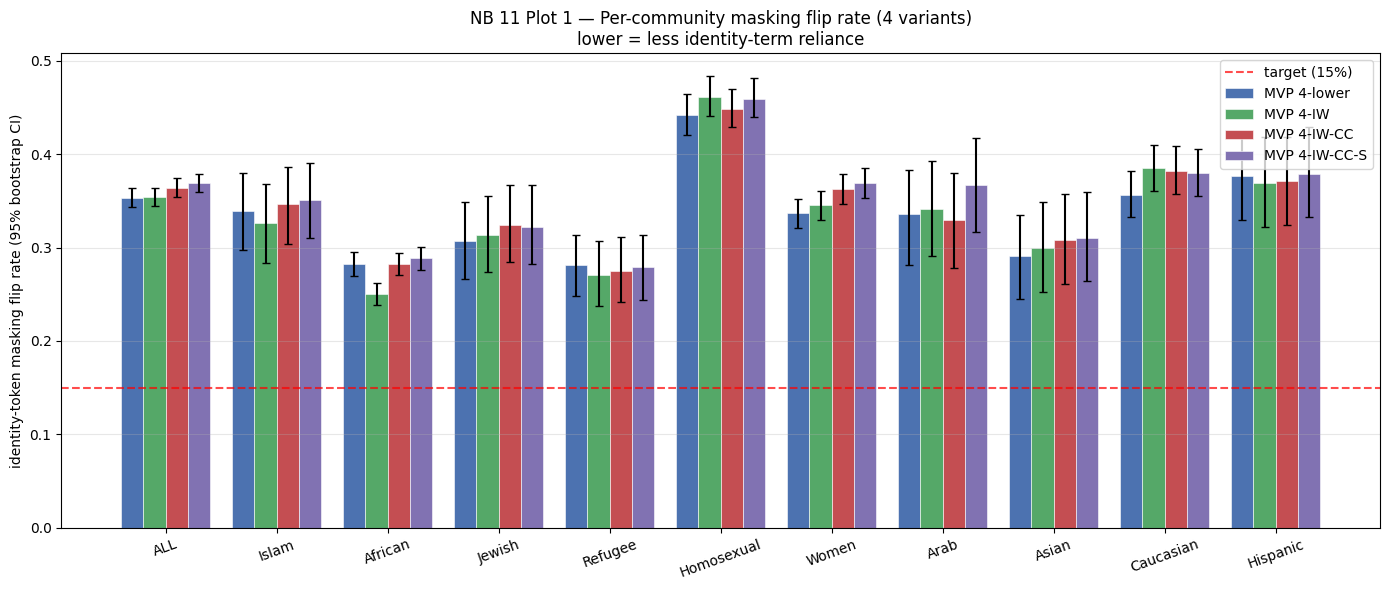

saved -> /teamspace/studios/this_studio/HateFusion/outputs/nb11/01_masking_flip_rate.png


In [8]:
# Cell 9: Plot 1 — per-community flip rate (grouped bar) with 15% reference line
fig, ax = plt.subplots(figsize=(14, 6))
variants_ord = [v["name"] for v in VARIANTS]
variant_colors = {"mvp4_lower":"#4C72B0","mvp4_iw":"#55A868","mvp4_iwcc":"#C44E52","mvp4_iwccs":"#8172B2"}
variant_labels_dict = {"mvp4_lower":"MVP 4-lower","mvp4_iw":"MVP 4-IW","mvp4_iwcc":"MVP 4-IW-CC","mvp4_iwccs":"MVP 4-IW-CC-S"}
x = np.arange(len(COMMUNITIES_TOP10) + 1)  # +1 for ALL
x_labels = ["ALL"] + COMMUNITIES_TOP10
width = 0.20
for i, vname in enumerate(variants_ord):
    sub = masking_summary[masking_summary["variant"] == vname]
    sub_map = sub.set_index("community")
    flip_rates = [sub_map.loc[c, "flip_rate"] if c in sub_map.index else 0 for c in x_labels]
    lo = [sub_map.loc[c, "ci_lo"] if c in sub_map.index else 0 for c in x_labels]
    hi = [sub_map.loc[c, "ci_hi"] if c in sub_map.index else 0 for c in x_labels]
    err = np.array([np.array(flip_rates) - np.array(lo), np.array(hi) - np.array(flip_rates)])
    ax.bar(x + (i - 1.5) * width, flip_rates, width, yerr=err,
           color=variant_colors[vname], label=variant_labels_dict[vname], capsize=3, edgecolor="white", linewidth=0.4)
ax.axhline(HPARAMS["masking_target"], color="red", linestyle="--", alpha=0.7,
           label=f'target ({100*HPARAMS["masking_target"]:.0f}%)')
ax.set_xticks(x); ax.set_xticklabels(x_labels, rotation=20)
ax.set_ylabel("identity-token masking flip rate (95% bootstrap CI)")
ax.set_title("NB 11 Plot 1 — Per-community masking flip rate (4 variants)\nlower = less identity-term reliance")
ax.legend(loc="upper right"); ax.grid(axis="y", alpha=0.3); ax.set_ylim(0, max(0.4, ax.get_ylim()[1]))
plt.tight_layout()
plt.savefig(OUT_DIR / "01_masking_flip_rate.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"saved -> {OUT_DIR / '01_masking_flip_rate.png'}")

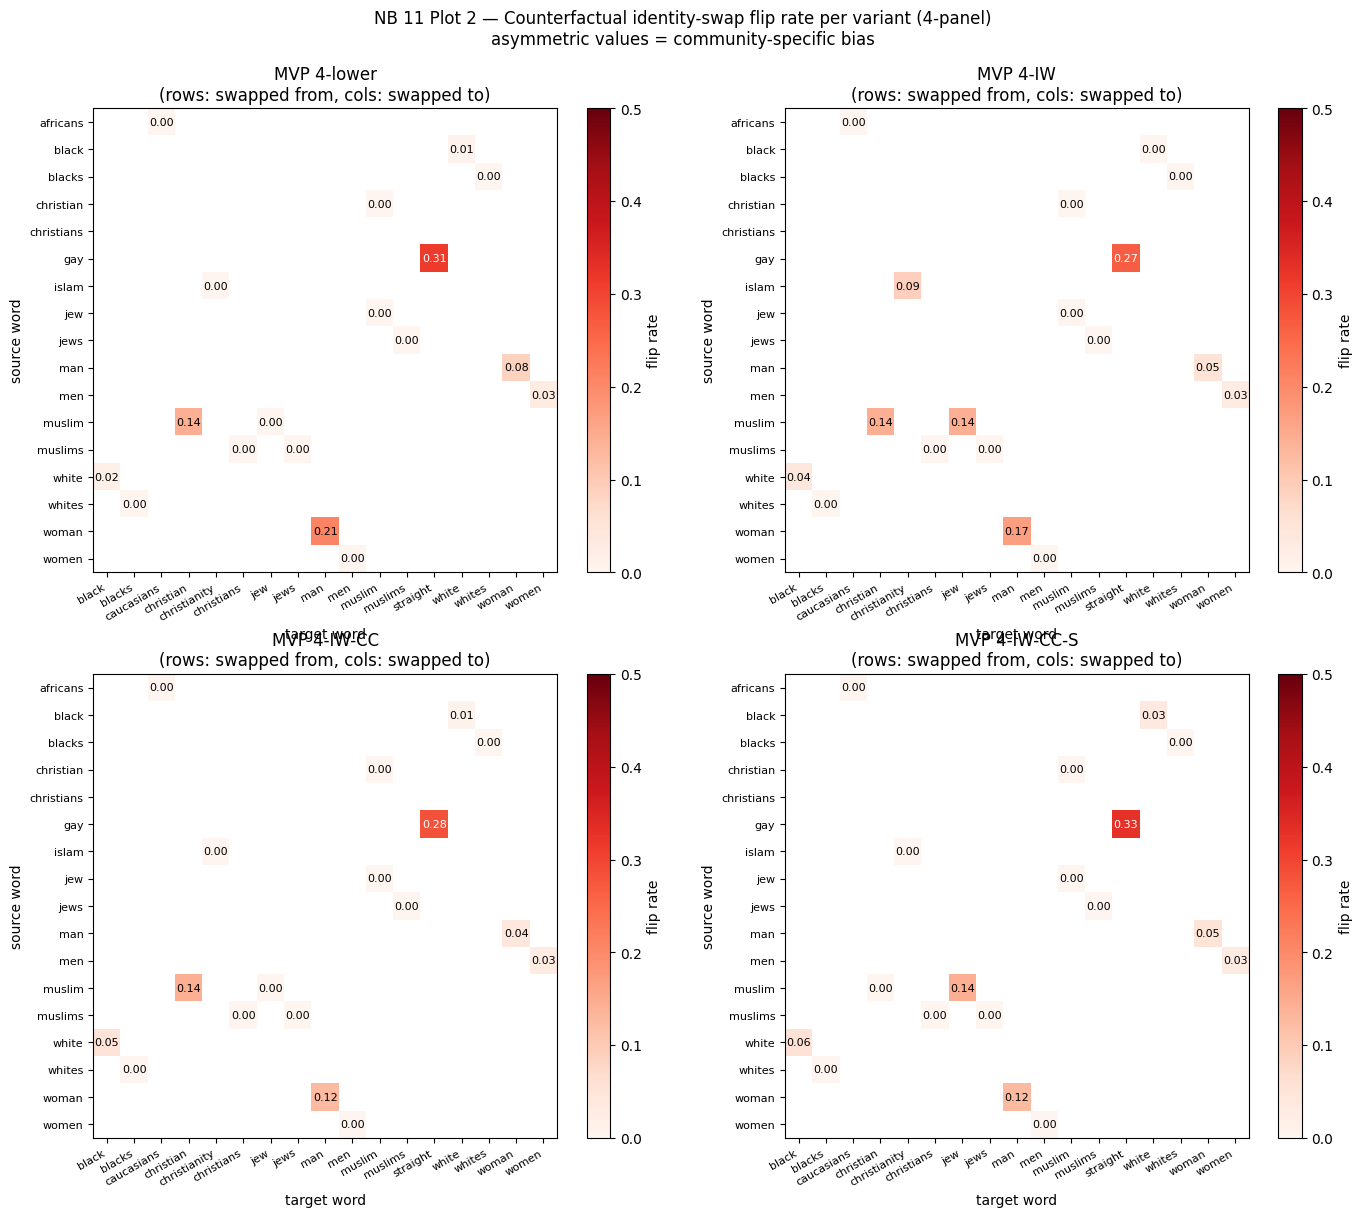

saved -> /teamspace/studios/this_studio/HateFusion/outputs/nb11/02_swap_asymmetry.png


In [9]:
# Cell 10: Plot 2 — swap-pair asymmetry (4-panel grid heatmap)
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()
# Build a per-variant swap-pair matrix: src-rows × tgt-cols, cell = flip_rate
srcs_used = sorted({s for s, t in SWAP_PAIRS_VALID})
tgts_used = sorted({t for s, t in SWAP_PAIRS_VALID})
for ax, vcfg in zip(axes, VARIANTS):
    vname = vcfg["name"]
    sub = swap_all[swap_all["variant"] == vname]
    pairwise = sub.groupby(["src","tgt"])["flipped"].mean().reset_index().rename(columns={"flipped": "flip_rate"})
    M = np.full((len(srcs_used), len(tgts_used)), np.nan)
    for _, r in pairwise.iterrows():
        i = srcs_used.index(r["src"]); j = tgts_used.index(r["tgt"])
        M[i, j] = r["flip_rate"]
    im = ax.imshow(M, cmap="Reds", vmin=0, vmax=0.5)
    for i in range(len(srcs_used)):
        for j in range(len(tgts_used)):
            if not np.isnan(M[i,j]):
                ax.text(j, i, f"{M[i,j]:.2f}", ha="center", va="center",
                        color="white" if M[i,j] > 0.25 else "black", fontsize=8)
    ax.set_xticks(range(len(tgts_used))); ax.set_xticklabels(tgts_used, rotation=30, ha="right", fontsize=8)
    ax.set_yticks(range(len(srcs_used))); ax.set_yticklabels(srcs_used, fontsize=8)
    ax.set_xlabel("target word"); ax.set_ylabel("source word")
    ax.set_title(f"{vcfg['label']}\n(rows: swapped from, cols: swapped to)")
    fig.colorbar(im, ax=ax, label="flip rate")
plt.suptitle("NB 11 Plot 2 — Counterfactual identity-swap flip rate per variant (4-panel)\nasymmetric values = community-specific bias", y=1.00)
plt.tight_layout()
plt.savefig(OUT_DIR / "02_swap_asymmetry.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"saved -> {OUT_DIR / '02_swap_asymmetry.png'}")

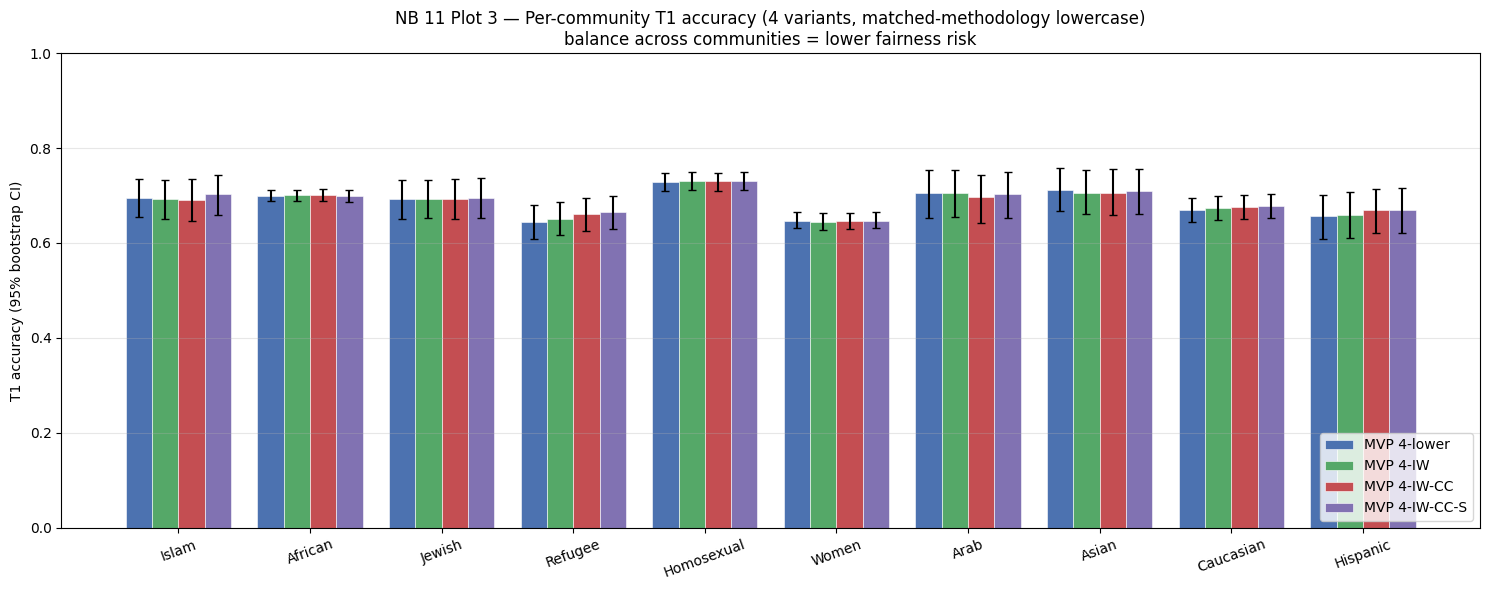

saved -> /teamspace/studios/this_studio/HateFusion/outputs/nb11/03_per_community_accuracy.png


In [10]:
# Cell 11: Plot 3 — per-community T1 accuracy (grouped bar with CIs)
fig, ax = plt.subplots(figsize=(15, 6))
x = np.arange(len(COMMUNITIES_TOP10)); width = 0.20
for i, vcfg in enumerate(VARIANTS):
    vname = vcfg["name"]
    sub = per_community_df[per_community_df["variant"] == vname].set_index("community")
    accs = [sub.loc[c, "t1_acc"] if c in sub.index else 0 for c in COMMUNITIES_TOP10]
    los  = [sub.loc[c, "t1_acc_lo"] if c in sub.index else 0 for c in COMMUNITIES_TOP10]
    his  = [sub.loc[c, "t1_acc_hi"] if c in sub.index else 0 for c in COMMUNITIES_TOP10]
    err = np.array([np.array(accs) - np.array(los), np.array(his) - np.array(accs)])
    ax.bar(x + (i - 1.5) * width, accs, width, yerr=err,
           color=variant_colors[vname], label=variant_labels_dict[vname], capsize=3, edgecolor="white", linewidth=0.4)
ax.set_xticks(x); ax.set_xticklabels(COMMUNITIES_TOP10, rotation=20)
ax.set_ylabel("T1 accuracy (95% bootstrap CI)")
ax.set_title("NB 11 Plot 3 — Per-community T1 accuracy (4 variants, matched-methodology lowercase)\nbalance across communities = lower fairness risk")
ax.set_ylim(0, 1.0); ax.legend(loc="lower right"); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "03_per_community_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"saved -> {OUT_DIR / '03_per_community_accuracy.png'}")

In [11]:
# Cell 12: write tables + summary
md1 = "# NB 11 Table 1 — Per-Community Masking Flip Rate (95% bootstrap CI)\n\n"
md1 += "Flip rate = % of identity-laden test samples where T1 fused prediction changes when identity-tagged BPE tokens are replaced with `<mask>`.\n\n"
md1 += "| Variant | Community | n | Flip rate [95% CI] |\n|---|---|---:|---|\n"
for _, r in masking_summary.iterrows():
    md1 += f"| {r['variant']} | {r['community']} | {int(r['n']):,} | {r['flip_rate']:.4f} [{r['ci_lo']:.4f}, {r['ci_hi']:.4f}] |\n"
with open(OUT_DIR / "table_1_masking.md", "w") as f: f.write(md1)
print(f"saved -> {OUT_DIR / 'table_1_masking.md'}")

md2 = "# NB 11 Table 2 — Counterfactual Identity-Swap Flip Rate\n\n"
md2 += "Flip rate = % of test samples (containing the source word) where T1 fused prediction changes after swapping source → target.\n\n"
md2 += "| Source | Target | Variant | n | Flip rate |\n|---|---|---|---:|---:|\n"
for _, r in swap_pair_summary.iterrows():
    md2 += f"| {r['src']} | {r['tgt']} | {r['variant']} | {int(r['n']):,} | {r['flip_rate']:.4f} |\n"
with open(OUT_DIR / "table_2_swap.md", "w") as f: f.write(md2)
print(f"saved -> {OUT_DIR / 'table_2_swap.md'}")

md3 = "# NB 11 Table 3 — Per-Community Performance (T1 acc + FPR + T2 macro F1, 95% bootstrap CI)\n\n"
md3 += "All numbers from the NB 10-lower per-sample parquet on matched-methodology lowercase test set.\n\n"
md3 += "| Variant | Community | n | n_t2_valid | T1 acc [95% CI] | T1 FPR [95% CI] | T2 macro F1 [95% CI] |\n|---|---|---:|---:|---|---|---|\n"
for _, r in per_community_df.iterrows():
    md3 += (f"| {r['variant']} | {r['community']} | {int(r['n']):,} | {int(r['n_t2_valid']):,} | "
            f"{r['t1_acc']:.4f} [{r['t1_acc_lo']:.4f}, {r['t1_acc_hi']:.4f}] | "
            f"{r['t1_fpr']:.4f} [{r['t1_fpr_lo']:.4f}, {r['t1_fpr_hi']:.4f}] | "
            f"{r['t2_macro']:.4f} [{r['t2_macro_lo']:.4f}, {r['t2_macro_hi']:.4f}] |\n")
with open(OUT_DIR / "table_3_per_community.md", "w") as f: f.write(md3)
print(f"saved -> {OUT_DIR / 'table_3_per_community.md'}")


# Summary findings
overall_flip = {v: masking_summary[(masking_summary["variant"] == v) & (masking_summary["community"] == "ALL")]["flip_rate"].iloc[0]
                for v in [vc["name"] for vc in VARIANTS]}
# Highest / lowest per-community flip per variant (excl ALL)
ms_excl = masking_summary[masking_summary["community"] != "ALL"]
highest_per_var = ms_excl.loc[ms_excl.groupby("variant")["flip_rate"].idxmax()][["variant","community","flip_rate"]]
lowest_per_var  = ms_excl.loc[ms_excl.groupby("variant")["flip_rate"].idxmin()][["variant","community","flip_rate"]]
# IW-CC-S vs MVP 4-lower per-community delta
iwccs_pc = per_community_df[per_community_df["variant"] == "mvp4_iwccs"].set_index("community")
mvp4l_pc = per_community_df[per_community_df["variant"] == "mvp4_lower"].set_index("community")
deltas = []
for c in COMMUNITIES_TOP10:
    if c in iwccs_pc.index and c in mvp4l_pc.index:
        d = iwccs_pc.loc[c,"t1_acc"] - mvp4l_pc.loc[c,"t1_acc"]
        deltas.append((c, d))

summary = []
summary.append("# NB 11 — Bias / Fairness Robustness Analysis — Summary findings\n")
summary.append("## 1. Overall masking flip rate per variant\n")
summary.append("Flip rate = fraction of identity-laden samples where T1 prediction changes when identity tokens are masked.\n")
for v in [vc["name"] for vc in VARIANTS]:
    summary.append(f"- **{variant_labels_dict[v]}**: {overall_flip[v]:.4f}\n")
summary.append("\n")
summary.append("## 2. Communities with highest flip rate (most identity-sensitive)\n")
for _, r in highest_per_var.iterrows():
    summary.append(f"- {variant_labels_dict[r['variant']]}: **{r['community']}** at {r['flip_rate']:.4f}\n")
summary.append("\n")
summary.append("## 3. Communities with lowest flip rate (least identity-sensitive)\n")
for _, r in lowest_per_var.iterrows():
    summary.append(f"- {variant_labels_dict[r['variant']]}: **{r['community']}** at {r['flip_rate']:.4f}\n")
summary.append("\n")
summary.append("## 4. MVP 4-IW-CC-S vs MVP 4-lower per-community T1 accuracy deltas\n")
summary.append("Given bias-off ablation (Δ = +0.0002 NotHate F1), expect minimal differences.\n\n")
summary.append("| Community | Δ T1 acc (IWCCS − MVP4-lower) |\n|---|---:|\n")
for c, d in deltas:
    summary.append(f"| {c} | {d:+.4f} |\n")
summary.append("\n")
mean_abs = float(np.mean([abs(d) for _, d in deltas]))
summary.append(f"Mean absolute Δ: {mean_abs:.4f}\n\n")
summary.append("## 5. Cross-community swap asymmetries\n")
# Show top-3 most asymmetric pairs (where flip(src→tgt) - flip(tgt→src) is largest)
swap_means = swap_all.groupby(["src","tgt","variant"])["flipped"].mean().reset_index()
# Find reciprocal pairs
asym_rows = []
for (s, t), _ in swap_means.groupby(["src","tgt"]):
    for v in [vc["name"] for vc in VARIANTS]:
        fwd = swap_means[(swap_means["src"]==s)&(swap_means["tgt"]==t)&(swap_means["variant"]==v)]["flipped"]
        rev = swap_means[(swap_means["src"]==t)&(swap_means["tgt"]==s)&(swap_means["variant"]==v)]["flipped"]
        if len(fwd) and len(rev):
            asym_rows.append({"pair": f"{s} ↔ {t}", "variant": v,
                              "asym": abs(float(fwd.iloc[0]) - float(rev.iloc[0]))})
asym_df = pd.DataFrame(asym_rows).sort_values("asym", ascending=False).head(8)
if len(asym_df):
    summary.append("Top asymmetric reciprocal swap pairs (|forward − reverse| flip rate):\n\n")
    summary.append("| Pair | Variant | Asymmetry |\n|---|---|---:|\n")
    for _, r in asym_df.iterrows():
        summary.append(f"| {r['pair']} | {variant_labels_dict.get(r['variant'], r['variant'])} | {r['asym']:.4f} |\n")
summary.append("\n")
summary.append("## 6. Per-community performance disparities\n")
worst_per_var, best_per_var = {}, {}
for v in [vc["name"] for vc in VARIANTS]:
    sub = per_community_df[per_community_df["variant"] == v]
    if len(sub):
        worst_per_var[v] = (sub.loc[sub["t1_acc"].idxmin(), "community"], sub["t1_acc"].min())
        best_per_var[v]  = (sub.loc[sub["t1_acc"].idxmax(), "community"], sub["t1_acc"].max())
summary.append("| Variant | Best community | Worst community | Disparity |\n|---|---|---|---:|\n")
for v in [vc["name"] for vc in VARIANTS]:
    if v in worst_per_var:
        disp = best_per_var[v][1] - worst_per_var[v][1]
        summary.append(f"| {variant_labels_dict[v]} | {best_per_var[v][0]} ({best_per_var[v][1]:.4f}) | {worst_per_var[v][0]} ({worst_per_var[v][1]:.4f}) | {disp:.4f} |\n")

summary_text = "".join(summary)
with open(OUT_DIR / "summary.md", "w") as f: f.write(summary_text)
print("\n" + summary_text)
print(f"\nsaved -> {OUT_DIR / 'summary.md'}")
print("NB 11 done.")

saved -> /teamspace/studios/this_studio/HateFusion/outputs/nb11/table_1_masking.md
saved -> /teamspace/studios/this_studio/HateFusion/outputs/nb11/table_2_swap.md
saved -> /teamspace/studios/this_studio/HateFusion/outputs/nb11/table_3_per_community.md



# NB 11 — Bias / Fairness Robustness Analysis — Summary findings
## 1. Overall masking flip rate per variant
Flip rate = fraction of identity-laden samples where T1 prediction changes when identity tokens are masked.
- **MVP 4-lower**: 0.3534
- **MVP 4-IW**: 0.3539
- **MVP 4-IW-CC**: 0.3635
- **MVP 4-IW-CC-S**: 0.3691

## 2. Communities with highest flip rate (most identity-sensitive)
- MVP 4-IW: **Homosexual** at 0.4614
- MVP 4-IW-CC: **Homosexual** at 0.4487
- MVP 4-IW-CC-S: **Homosexual** at 0.4595
- MVP 4-lower: **Homosexual** at 0.4419

## 3. Communities with lowest flip rate (least identity-sensitive)
- MVP 4-IW: **African** at 0.2506
- MVP 4-IW-CC: **Refugee** at 0.2751
- MVP 4-IW-CC-S: **Refugee** at 0.2794
- MVP 4-lower: **Refugee** at 0.2808

## 4. MVP 4-IW-CC-S vs MVP 4-lower per-community T1 accuracy deltas
Given bias-off ablation (Δ = +0.0002 NotHate F1), expect minimal differences.

| Community | Δ T1 acc (IWCCS − MVP4-lower) |
|---|---:|
| Islam | +0.0083 |
| African | 